# Polarization-Multiplexed Holography — Dual Reconstructions

This notebook is the **holography extension notebook**. It builds directly on
[hologram_coherent_logo.ipynb](hologram_coherent_logo.ipynb): the propagation problem is the same,
but the optical element is now a **Jones-matrix hologram** that sends different images to the two
linear polarization components.

### Assumes you know

- the phase-only holography setup from [hologram_coherent_logo.ipynb](hologram_coherent_logo.ipynb),
- how normalized intensity matching is used as the reconstruction loss, and
- the basics of Jones-vector polarization notation.

### What changes relative to the parent notebook

- the input field carries both `x` and `y` polarization components,
- the hologram is a diagonal Jones matrix rather than a scalar phase mask, and
- the loss supervises **two reconstructions at once**, one per polarization channel.

The parent notebook covers the phase-only holography intuition, so this notebook focuses only on the
polarization-specific delta.


## 0  Imports

The imports match the single-channel hologram notebook, with the same JAX/Optax optimization stack
and PIL image loading. The new ingredient is not a new dependency, but a different `fouriax`
optical layer: `JonesMatrixLayer`.


In [1]:
from __future__ import annotations

import argparse
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from PIL import Image

import fouriax as fx

import os
from pathlib import Path as _Path
%matplotlib inline

REPO_ROOT = fx.utils.find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


## 1  Paths and Parameters

The grid, wavelength, propagation distance, and optimization settings mirror the scalar hologram
example so the change in behavior can be attributed to polarization multiplexing rather than a new
numerical regime.


In [2]:
IMAGE_PATH = Path('/Users/liam/Downloads/logo.jpg')
ARTIFACTS_DIR = Path('artifacts')
PLOT_PATH = ARTIFACTS_DIR / "holography_polarized_dual_overview.png"

SEED = 0
NX = 128
NY = 128
DX_UM = 1.0
DY_UM = 1.0
WAVELENGTH_UM = 0.532
DISTANCE_UM = 1200.0
NYQUIST_FACTOR = 2.0
MIN_PADDING_FACTOR = 2.0
STEPS = 400
LR = 0.03
PLOT = True


## 2  Helper Functions

We reuse the same logo-to-binary-mask conversion as the parent notebook. The second target is then
created by rotating the first one by $180^\circ$, giving the two polarization channels clearly
separable objectives.


In [3]:
def load_logo_target(path: Path, grid: fx.Grid) -> jnp.ndarray:
    """Load image and convert to binary target: white->0, red-logo->1."""
    img = Image.open(path).convert("RGB").resize((grid.nx, grid.ny), Image.Resampling.BILINEAR)
    rgb = np.asarray(img, dtype=np.float32) / 255.0
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]
    red_mask = (r >= 0.55) & (g <= 0.45) & (b <= 0.45)
    return jnp.asarray(red_mask.astype(np.float32), dtype=jnp.float32)


## 3  Setup

The input is now a Jones field with both `E_x` and `E_y` present. The trainable optic is a
pixelwise diagonal Jones matrix

$$
J(x,y) = \begin{bmatrix}
 e^{i\phi_x(x,y)} & 0 \\
 0 & e^{i\phi_y(x,y)}
\end{bmatrix},
$$

so the two polarization channels see different phase delays while remaining uncoupled.

This is the key difference from the parent notebook: one physical surface carries **two** phase maps,
one for each polarization basis component.


In [4]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"image not found: {IMAGE_PATH}")

grid = fx.Grid.from_extent(nx=NX, ny=NY, dx_um=DX_UM, dy_um=DY_UM)
base_target = load_logo_target(IMAGE_PATH, grid=grid)
target_x = base_target
target_y = jnp.rot90(base_target, k=2, axes=(0, 1))

spectrum = fx.Spectrum.from_scalar(WAVELENGTH_UM)

field_in = fx.Field.plane_wave_jones(
    grid=grid,
    spectrum=spectrum,
    ex=1.0 + 0.0j,
    ey=1.0 + 0.0j,
)
propagator = fx.plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
    nyquist_factor=NYQUIST_FACTOR,
    min_padding_factor=MIN_PADDING_FACTOR,
)

def build_module(raw_phase: jnp.ndarray) -> fx.OpticalModule:
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    jxx = jnp.exp(1j * phase[0]).astype(jnp.complex64)
    jyy = jnp.exp(1j * phase[1]).astype(jnp.complex64)
    zeros = jnp.zeros_like(jxx)
    jones = jnp.stack(
        [
            jnp.stack([jxx, zeros], axis=0),
            jnp.stack([zeros, jyy], axis=0),
        ],
        axis=0,
    )
    return fx.OpticalModule(
        layers=(
            fx.JonesMatrixLayer(jones_matrix=jones),
            propagator,
        )
    )


## 4  Loss Function and Optimization

The loss propagates the Jones field, extracts the per-component intensities, normalizes each one
independently, and matches them to `target_x` and `target_y`.

Training therefore asks a stronger question than the scalar hologram example: can one shared device
encode two independent images when read through polarization analysis?


In [5]:
def loss_fn(raw_phase: jnp.ndarray) -> jnp.ndarray:
    module = build_module(raw_phase)
    out = module.forward(field_in)
    component_intensity = out.component_intensity()[0]
    ix = component_intensity[0]
    iy = component_intensity[1]
    ix_norm = ix / jnp.maximum(jnp.max(ix), 1e-12)
    iy_norm = iy / jnp.maximum(jnp.max(iy), 1e-12)
    return jnp.mean((ix_norm - target_x) ** 2) + jnp.mean((iy_norm - target_y) ** 2)

key = jax.random.PRNGKey(SEED)
raw_phase = 0.1 * jax.random.normal(key, (2, grid.ny, grid.nx), dtype=jnp.float32)
optimizer = optax.adam(LR)
result = fx.optim.optimize_optical_module(
    init_params=raw_phase,
    build_module=build_module,
    loss_fn=loss_fn,
    optimizer=optimizer,
    steps=STEPS,
    log_every=50,
)


step=000 loss=0.474987


step=050 loss=0.198434


step=100 loss=0.144278


step=150 loss=0.065695


step=200 loss=0.040990


step=250 loss=0.035248


step=300 loss=0.032215


step=350 loss=0.029542


step=399 loss=0.027540


## 5  Evaluation

After optimization, we convert the best raw parameters into the two physical phase maps
$\phi_x$ and $\phi_y$, then inspect the reconstructed intensities for both polarization channels.
This separates device design from readout: the figure shows what each analyzed component would
produce at the output plane.


In [6]:
phase_opt = 2.0 * jnp.pi * jax.nn.sigmoid(result.best_params)
out_opt = result.best_module.forward(field_in)
component_intensity = out_opt.component_intensity()[0]
recon_x = component_intensity[0]
recon_y = component_intensity[1]
recon_x_norm = recon_x / jnp.maximum(jnp.max(recon_x), 1e-12)
recon_y_norm = recon_y / jnp.maximum(jnp.max(recon_y), 1e-12)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


## 6  Plot Results

The top row reports the `x`-polarized target, reconstruction, and learned phase; the bottom row does
the same for the `y` channel. Success here means each polarization component reproduces its own
pattern without simply duplicating the other one.

The result demonstrates the main point of polarization multiplexing: the same pixel grid can carry
multiple holographic functions when the field has additional internal degrees of freedom.


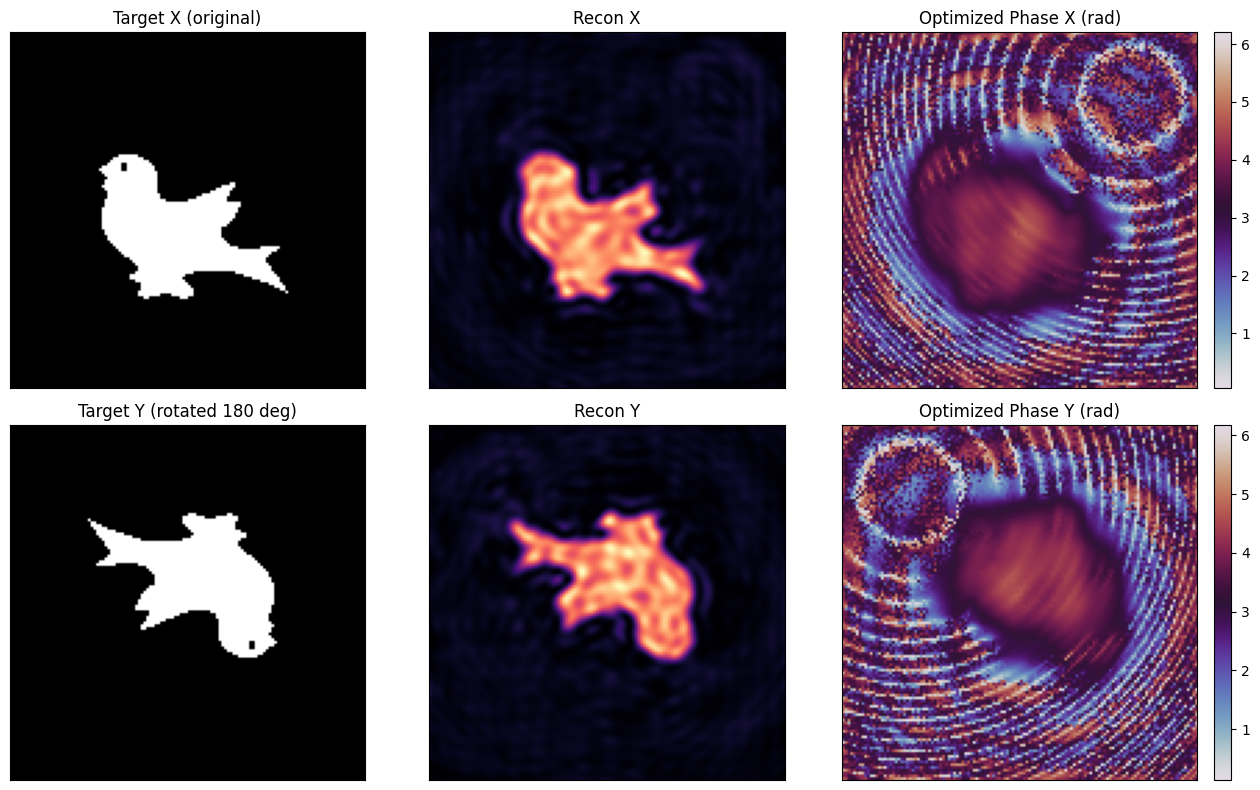

saved: artifacts/holography_polarized_dual_overview.png


In [7]:
if PLOT:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes[0, 0].imshow(np.asarray(target_x), cmap="gray", vmin=0.0, vmax=1.0)
    axes[0, 0].set_title("Target X (original)")
    axes[0, 1].imshow(np.asarray(recon_x_norm), cmap="magma", vmin=0.0, vmax=1.0)
    axes[0, 1].set_title("Recon X")
    sx_im = axes[0, 2].imshow(np.asarray(phase_opt[0]), cmap="twilight")
    axes[0, 2].set_title("Optimized Phase X (rad)")
    plt.colorbar(sx_im, ax=axes[0, 2], fraction=0.046, pad=0.04)

    axes[1, 0].imshow(np.asarray(target_y), cmap="gray", vmin=0.0, vmax=1.0)
    axes[1, 0].set_title("Target Y (rotated 180 deg)")
    axes[1, 1].imshow(np.asarray(recon_y_norm), cmap="magma", vmin=0.0, vmax=1.0)
    axes[1, 1].set_title("Recon Y")
    sy_im = axes[1, 2].imshow(np.asarray(phase_opt[1]), cmap="twilight")
    axes[1, 2].set_title("Optimized Phase Y (rad)")
    plt.colorbar(sy_im, ax=axes[1, 2], fraction=0.046, pad=0.04)

    for ax in axes.flatten():
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
